# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isnull().sum())
print(users.isnull().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage

print(usage.isnull().sum())
print(usage.isnull().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

 ---


 ### Diagnóstico

**Dataset `users`:**
* Las columnas `city` y `churn_date` presentan valores faltantes.
* En el caso de `city`, los valores faltantes corresponden al 11.7% del total de los datos. Por lo tanto, investigaré estos registros en detalle para decidir si es más conveniente imputarlos o ignorarlos.
* Para la columna `churn_date`, los datos faltantes representan un 88.35% del total. Dado este alto porcentaje, ignoraré esta columna para el resto del análisis.

**Dataset `usage`:**
* Las columnas `date`, `duration` y `length` presentan valores faltantes.
* En el caso de `date`, los valores faltantes son mínimos (0.125% del total), por lo que procederé a imputarlos.
* En cuanto a `duration`, los faltantes corresponden al 55.19%. Sin embargo, dado que este valor es dependiente de la columna `type`, investigaré su comportamiento antes de aplicar un tratamiento.
* Finalmente, para la columna `length`, los valores faltantes alcanzan el 44.74%. Al igual que en el caso anterior, esta carencia depende de la columna `type`, por lo que realizaré una exploración adicional para definir las acciones correspondientes.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
unicos = users['user_id'].nunique()
print('User_id diferentes:', unicos)
print('----------------------')
media = users['age'].mean()
mediana = users['age'].median()
max = users['age'].max()
min = users['age'].min()
print('Media de edad:', media)
print('Mediana de edad:', mediana)
print('Mayor edad:', max)
print('Menor edad:', min)
print()
print('Edad Apariciones')
print(users['age'].value_counts().sort_index())

User_id diferentes: 4000
----------------------
Media de edad: 33.73975
Mediana de edad: 47.0
Mayor edad: 79
Menor edad: -999

Edad Apariciones
-999    55
 18     65
 19     65
 20     64
 21     57
        ..
 75     62
 76     61
 77     58
 78     79
 79     59
Name: age, Length: 63, dtype: int64



- La columna `user_id` tiene 4000 valores diferentes, lo que indica que no se repiten user_id
- La columna `age` presenta datos con un valor negativo que se repite 55 veces, posiblemente una bandera para indicar que no esta disponible. El resto de edades entran en el rango humano razonable.


In [14]:
# explorar columnas numéricas de usage
print('id unicos:', usage['id'].nunique())
print('User_id unicos:', usage['user_id'].nunique())
print("------------------------------------")
print("Media de duration:", usage['duration'].mean())
print('Mediana de duration:', usage['duration'].median())
print("Maximo valor en duration", usage['duration'].max())
print("Minimo valor en duration", usage['duration'].min())
print("------------------------------------")
print("Media de length:", usage['length'].mean())
print('Mediana de length:', usage['length'].median())
print("Maximo valor en length", usage['length'].max())
print("Minimo valor en length", usage['length'].min())

id unicos: 40000
User_id unicos: 3999
------------------------------------
Media de duration: 5.202237223833965
Mediana de duration: 3.5
Maximo valor en duration 120.0
Minimo valor en duration 0.0
------------------------------------
Media de length: 52.12739775606225
Mediana de length: 50.0
Maximo valor en length 1490.0
Minimo valor en length 0.0


- Las columnas `id` y `user_id` contienen identificadores unicos, en el caso de id hay 40,000 resgistros diferentes, mientras que en user_id hay 3,999 valores únicos — hay muchos menos usuarios que registros, lo cual tiene sentido: cada usuario aparece varias veces (en promedio, cada usuario tiene ~10 registros: 40000/3999 ≈ 10)
- Las columnas `duration` y `length` muestran sesgo a la derecha con posibles valores atípicos en el extremo superior (120 en duration, 1490 en length). Para duration la media (5.2) es mayor que la mediana (3.5) lo cual indica una distribución con sesgo a la derecha (asimetría positiva). Hay valores altos que "jalan" el promedio hacia arriba. Mientras que para la columna length la media (52.1) es muy cercana a la mediana (50), lo que indica que la distribución es más simétrica que duration, aunque el máximo de 1490 es extremadamente alto comparado con la media, lo que indica presencia de outliers fuertes o una cola larga a la derecha.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print('Resumen de columnas categoricas en user:')
print(users[columnas_user].describe())
print('-------------------------------')
print('Frecuencia absoluta:')
for col in columnas_user:
    print(users[col].value_counts())
print('-------------------------------')
print('Frecuencia relativa:')
for col in columnas_user:
    print(users[col].value_counts(normalize=True))

Resumen de columnas categoricas en user:
          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595
-------------------------------
Frecuencia absoluta:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64
-------------------------------
Frecuencia relativa:
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64




- La columna `city` tiene 7 categorías, con una distribución relativamente pareja entre las principales: Bogotá (22.9%), CDMX (20.7%), Medellín (17.4%), GDL (12.7%), Cali (12.0%) y MTY (11.5%). Sin embargo, se detectó un valor "?" con 96 registros (2.7%), que en realidad es un sentinel (no una ciudad real) usado para representar dato desconocido. Sumando esto a los 469 nulos reales (NaN) detectados antes, la columna tiene en total 565 registros con ciudad faltante o inválida (14.1% del total)
- La columna `plan` tiene 2 categorías, sin valores nulos ni sentinels aparentes. Está desbalanceada hacia Básico (64.9%) frente a Premium (35.1%)



In [16]:
# explorar columna categórica de usage
print('Resumen de columnas categoricas en usage:')
print(usage['type'].describe())
print('-------------------------------')
print('Frecuencia absoluta:')
print(usage['type'].value_counts())
print('-------------------------------')
print('Frecuencia relativa:')
print(usage['type'].value_counts(normalize=True))

Resumen de columnas categoricas en usage:
count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
-------------------------------
Frecuencia absoluta:
text    22092
call    17908
Name: type, dtype: int64
-------------------------------
Frecuencia relativa:
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type` tiene 40,000 registros sin valores nulos y 2 categorías: text (55.2%, con 22,092 registros) y call (44.8%, con 17,908 registros). La distribución está relativamente balanceada entre ambas categorías, sin evidencia de valores sentinel o inválidos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
# Informe: Valores inválidos y sentinels

## ¿En qué columnas se encontraron valores inválidos o sentinels?

**1. `age` (dataset `users`)**
Se encontró el valor `-999` repetido 55 veces. Es un sentinel claro: una edad negativa no es posible, y el valor exacto -999 es un patrón típico usado para marcar "dato no disponible". El resto de las edades (18 a 79) están dentro de un rango humano razonable.

**2. `city` (dataset `users`)**
Se encontró el valor `"?"` en 96 registros (2.7%). Es un sentinel: no representa una ciudad real, sino un dato desconocido disfrazado como categoría válida. Sumado a los 469 nulos reales (NaN) ya detectados, la columna tiene en total 565 registros con ciudad faltante o inválida (~14.1% del total).

**3. `duration` y `length` (dataset `usage`)**
No se confirmaron sentinels explícitos, pero ambas columnas muestran sesgo a la derecha y valores máximos muy alejados del resto de los datos (120 en `duration`, 1490 en `length`), lo que sugiere posibles outliers o valores atípicos que deben revisarse con más detalle.

**4. `plan` y `type`**
No se encontraron valores inválidos, sentinels, ni nulos en estas columnas. Ambas están limpias y completas.

## ¿Qué acción se tomaría?

**Para `age`:**
Reemplazar el valor -999 por un nulo real (NaN), para que se trate como un dato faltante genuino y no distorsione las estadísticas (media, desviación, etc.). Luego decidir si se imputa (por ejemplo, con la mediana) o se excluye del análisis según el caso de uso.

**Para `city`:**
Reemplazar el valor "?" por un nulo real (NaN), de la misma manera que con `age`, y recalcular la proporción real de nulos en la columna.

**Para `duration` y `length`:**
Graficar boxplots o histogramas para visualizar la distribución y confirmar si los valores extremos (120, 1490) son outliers reales. También revisar si el valor 0 en ambas columnas es un dato legítimo o un sentinel disfrazado, idealmente consultando la documentación del dataset. Si se confirman como outliers, evaluar si conviene aplicar un límite superior (capping), transformar la variable, o simplemente dejarlos documentados si son casos legítimos.

**Para `plan` y `type`:**
No se requiere ninguna acción de limpieza; ambas columnas están listas para análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [19]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan registros distribuidos principalmente en tres años: 2024 (1,330), 2023 (1,316) y 2022 (1,314), con una distribución bastante pareja entre ellos. Sin embargo, aparece un grupo mucho más pequeño en el año 2026 (40 registros), lo cual llama la atención por dos razones: es un valor atípico en cantidad, muy inferior a los demás años, lo que podría indicar registros incompletos.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, todos los valores no nulos corresponden al año 2024 (39,950 registros).

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:


**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

## ¿Aparecen años imposibles?

**En `reg_date` (dataset `users`):** Sí, aparece el año **2026** con 40 registros. Dado que `usage` solo tiene datos de uso del año 2024, estos 40 usuarios registrados en 2026 no tienen ni pueden tener ningún registro de uso asociado — se registraron después del periodo que cubre el dataset de uso. Esto los convierte en registros no útiles para el análisis conjunto de ambos datasets, independientemente de si la fecha 2026 es "válida" o no en sí misma.

**En `date` (dataset `usage`):** No se detectan años imposibles, todos los valores no nulos están en 2024, coherente con el alcance del dataset.

## ¿Qué haría con ellas?

**Para los 40 registros de `reg_date` en 2026:**
Dado que no pueden tener actividad registrada en `usage` (que solo cubre 2024), lo más razonable es excluirlos del análisis que combine ambos datasets. Estos usuarios simplemente no aportan información sobre uso del servicio, ya que se registraron fuera del periodo observado.

**Para los 50 nulos en `date` (dataset `usage`):**
Esto se mantiene igual — son registros de uso con fecha faltante, pero sí pertenecen a usuarios que sí usaron el servicio en el período cubierto. Se puede decidir imputarlos o excluirlos según si la fecha específica es relevante para el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  

- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.


In [21]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, pd.NA)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [23]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NaT)

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
nulos_duration_by_type = usage['duration'].isna().groupby(usage['type']).mean()
print(nulos_duration_by_type)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [25]:
# Verificación MAR en usage (Missing At Random) para length
nulos_length_by_type = usage['length'].isna().groupby(usage['type']).mean()
print(nulos_length_by_type)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


# Diagnóstico de nulos en `duration` y `length`

## Verificación MAR para `duration`

Los nulos en `duration` están concentrados casi en su totalidad en los registros de tipo `text` (99.93%), mientras que los registros de tipo `call` prácticamente no presentan nulos (0%). Esto confirma que la ausencia de `duration` **depende directamente de la variable `type`**, por lo tanto se trata de un patrón **MAR (Missing At Random)**.

## Verificación MAR para `length`

De forma inversa, los nulos en `length` están concentrados casi en su totalidad en los registros de tipo `call` (99.93%), mientras que los registros de tipo `text` no presentan nulos (0%). Esto también confirma un patrón **MAR**, dependiente de `type`.

## Interpretación

Ambos resultados tienen sentido estructural y lógico:
- Un registro de tipo `text` (mensaje de texto) no tiene una "duración" en el mismo sentido que una llamada, por eso `duration` aparece nula en casi todos los mensajes de texto.
- Un registro de tipo `call` (llamada) no tiene una "longitud" en el sentido de caracteres o extensión de texto, por eso `length` aparece nula en casi todas las llamadas.

En ambos casos, el nulo **no representa un error de captura ni un dato perdido**, sino la ausencia esperada de una métrica que simplemente no aplica a ese tipo de evento.

## Decisión

Dado que se confirma el patrón MAR (dependencia total de `type`), la decisión correcta es **dejar estos valores como nulos (NaN)** y no imputarlos. Imputar `duration` en mensajes de texto o `length` en llamadas introduciría valores falsos y sin sentido para ese tipo de evento.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
col_numericas = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[col_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) *100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

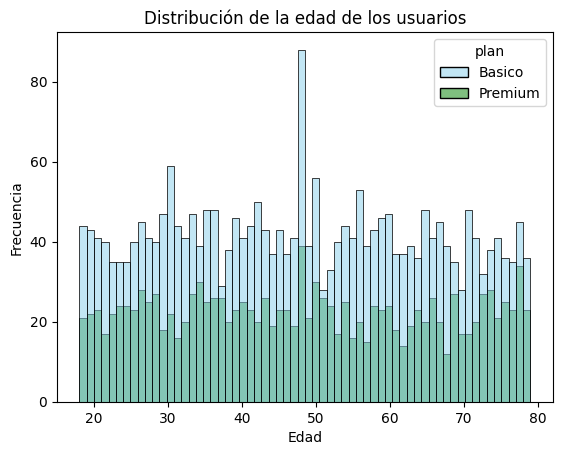

In [31]:
# Histograma para visualizar la edad (age)
sns.histplot(data = user_profile, x='age', bins=62, hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de la edad de los usuarios')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
1. **Distribución generalmente uniforme**
La mayoría de las edades, entre 18 y 79 años aproximadamente, muestran una frecuencia bastante consistente, oscilando entre 45 y 80 usuarios por edad individual. No hay un grupo etario claramente dominante dentro de este rango.

2. **Pico inusual alrededor de los 47-50 años**
Se observa una barra que sobresale claramente en esta zona. Esto probablemente no es un patrón natural de los datos, sino un efecto de la limpieza que hicimos antes, cuando reemplazamos los 55 valores `-999` (sentinels) por la mediana de la edad, que era justamente 47. Esto genera un pico artificial en ese valor, ya que ahora hay más registros concentrados ahí de los que habría naturalmente.

3. **El plan Básico domina consistentemente sobre Premium en casi todo el rango de edad**
Independientemente del pico artificial, se observa que la categoría Básico tiene una frecuencia mayor que Premium en prácticamente todas las edades, lo cual es coherente con la proporción general que vimos antes (64.9% Básico vs 35.1% Premium). Esta relación se mantiene estable a lo largo de todo el rango etario, sin que ningún grupo de edad muestre una preferencia marcada hacia Premium.

4. **Sin diferencias evidentes en la forma de la distribución por plan**
Más allá del pico artificial, tanto Básico como Premium muestran una distribución de edad con una forma similar (relativamente uniforme a lo largo del rango de 18 a 78 años), lo que sugiere que el tipo de plan **no está fuertemente asociado con la edad del usuario** — ambos planes atraen usuarios de todas las edades de forma parecida.1. **Distribución generalmente uniforme**
La mayoría de las edades, entre 18 y 79 años aproximadamente, muestran una frecuencia bastante consistente, oscilando entre 45 y 80 usuarios por edad individual. No hay un grupo etario claramente dominante dentro de este rango.


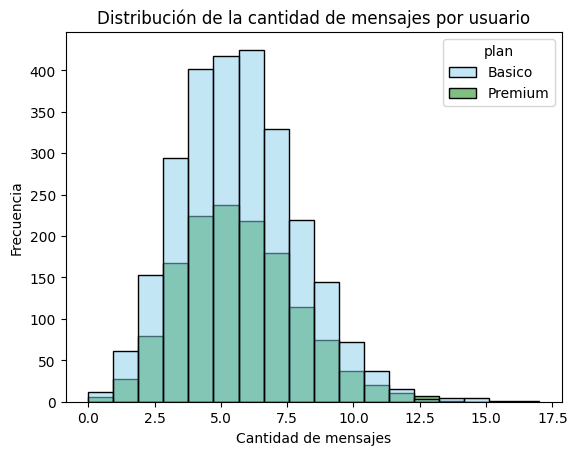

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data = user_profile, x='cant_mensajes', bins=18, hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de la cantidad de mensajes por usuario')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 

## Insights de la cantidad de mensajes por usuario

1. **Ambos planes muestran una distribución con sesgo positivo (a la derecha)**
Tanto Básico como Premium presentan una distribución unimodal con el pico (moda) concentrado entre 4 y 7 mensajes aproximadamente, pero con una cola larga hacia la derecha que se extiende hasta los 15-17 mensajes. Esta forma es característica de una **asimetría positiva**.

2. **Básico tiene mayor frecuencia absoluta, pero es consistente con su proporción en la base de usuarios**
Básico muestra barras más altas que Premium en casi todo el rango (por ejemplo, ~425 usuarios Básico vs ~220 Premium en la franja de 6-7 mensajes). Sin embargo, esto es esperable, ya que Básico representa el 64.9% del total de usuarios frente al 35.1% de Premium.

3. **La cola derecha (usuarios con muchos mensajes) es similar en ambos planes**
Después de los 10-12 mensajes, ambos planes muestran una caída fuerte en frecuencia, y prácticamente desaparecen después de los 15 mensajes. Esto confirma que el sesgo a la derecha, aunque presente en ambos, involucra una **proporción pequeña de valores atípicos altos** (posibles "power users"), sin que ningún plan concentre claramente a este grupo, ni en términos absolutos ni relativos a su tamaño.



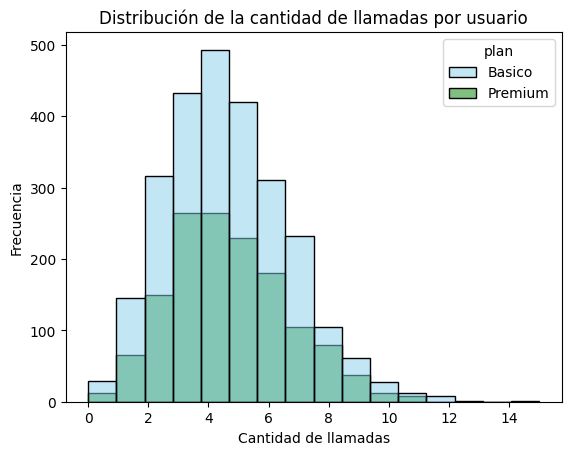

In [33]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data = user_profile, x='cant_llamadas', bins=16, hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de la cantidad de llamadas por usuario')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
## Insights de la cantidad de llamadas por usuario

1. **Ambos planes muestran una distribución con sesgo positivo (a la derecha)**
Tanto Básico como Premium presentan una distribución unimodal con el pico (moda) concentrado entre 3 y 5 llamadas aproximadamente, pero con una cola larga hacia la derecha que se extiende hasta las 14-15 llamadas. Esta forma es característica de una asimetría positiva.

2. **Básico tiene mayor frecuencia absoluta, pero es consistente con su proporción en la base de usuarios**
Básico muestra barras más altas que Premium en casi todo el rango (por ejemplo, ~495 usuarios Básico vs ~265 Premium en la franja de 4-5 llamadas). Sin embargo, esto es esperable, ya que Básico representa el 64.9% del total de usuarios frente al 35.1% de Premium.

3. **La cola derecha (usuarios con muchas llamadas) es similar en ambos planes**
Después de las 8-9 llamadas, ambos planes muestran una caída fuerte en frecuencia, y prácticamente desaparecen después de las 12 llamadas. Esto confirma que el sesgo a la derecha, aunque presente en ambos, involucra una proporción pequeña de valores atípicos altos, sin que ningún plan concentre claramente a este grupo, ni en términos absolutos ni relativos a su tamaño.

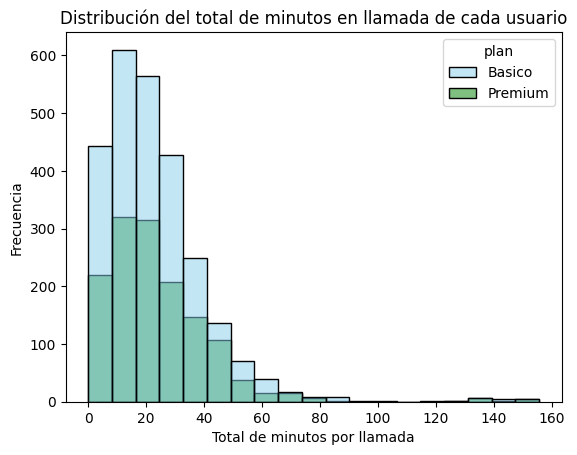

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data = user_profile, x='cant_minutos_llamada', bins=19, hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución del total de minutos en llamada de cada usuario')
plt.xlabel('Total de minutos por llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
## Insights de la distribución del total de minutos en llamada

1. **Ambos planes muestran una distribución con sesgo positivo (a la derecha)**
Tanto Básico como Premium presentan una distribución unimodal con el pico (moda) concentrado entre 10 y 20 minutos aproximadamente, pero con una cola larga hacia la derecha que se extiende hasta los 150-160 minutos. Esta forma es característica de una asimetría positiva marcada.

2. **Básico tiene mayor frecuencia absoluta en los valores bajos, consistente con su proporción en la base de usuarios**
Básico muestra barras más altas que Premium en el rango de 0 a 40 minutos aproximadamente (por ejemplo, ~610 usuarios Básico vs ~320 Premium en la franja de 10-20 minutos), lo cual es esperable dado que Básico representa el 64.9% del total de usuarios frente al 35.1% de Premium.

3. **Se observa un ligero repunte en la cola derecha para el plan Premium**
A diferencia de los histogramas anteriores (mensajes y llamadas), aquí aparece un pequeño grupo de usuarios Premium con valores muy altos (entre 120 y 155 minutos aproximadamente) donde la frecuencia de Básico ya es prácticamente nula. Esto sugiere la posible existencia de un segmento de usuarios Premium con un comportamiento de uso mucho más intensivo en minutos de llamada — un patrón que no se observa de forma equivalente en Básico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

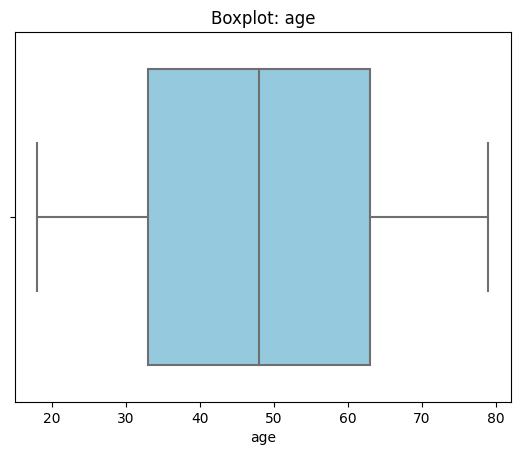

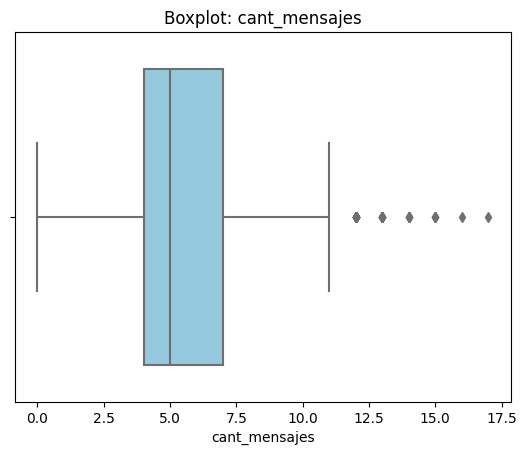

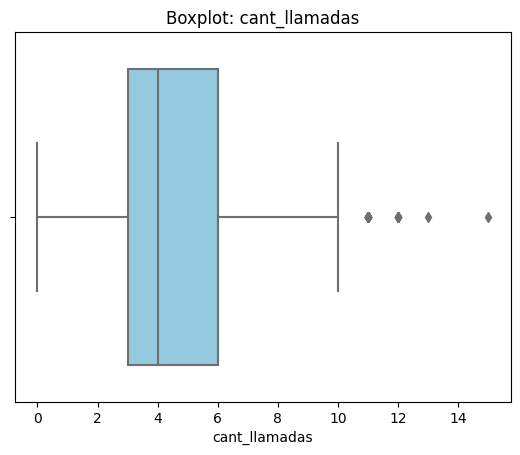

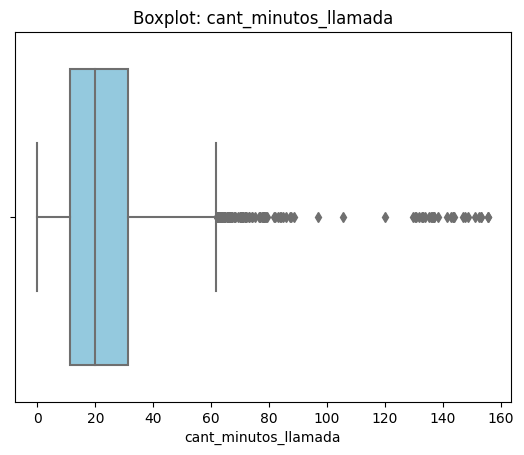

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col],color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
## Insights a partir de los outliers en los boxplots

**1. `age` — Sin outliers**
No se observan puntos atípicos en este boxplot; los bigotes cubren todo el rango de datos. Esto es coherente con lo que ya sabíamos: una vez tratado el sentinel `-999`, la edad se mantiene dentro de un rango humano razonable y sin valores extremos, algo esperable para una variable como esta.

**2. `cant_mensajes` — Outliers moderados en el extremo superior**
Se observan varios puntos atípicos a partir de aproximadamente 12 mensajes en adelante (12, 13, 14, 15, 16, 17). Estos representan usuarios que envían una cantidad de mensajes notablemente mayor al resto (el rango intercuartílico se concentra entre ~4 y ~7 mensajes). Son relativamente pocos casos, pero consistentes con la cola derecha que ya habíamos identificado en el histograma — posibles usuarios con un uso más intensivo de mensajería.

**3. `cant_llamadas` — Outliers similares a mensajes, en menor cantidad**
Aparecen outliers a partir de aproximadamente 11 llamadas (11, 12, 13, 15). Al igual que en mensajes, son pocos usuarios los que se alejan del resto (rango intercuartílico entre ~3 y ~6 llamadas), reflejando el mismo patrón de cola derecha con un grupo pequeño de usuarios más activos en llamadas.

**4. `cant_minutos_llamada` — Outliers mucho más numerosos y extendidos**
Esta es la variable con la mayor cantidad de outliers y el rango más amplio: se observan puntos atípicos desde aproximadamente 65 minutos hasta 155 minutos, con una alta densidad de casos entre 65-90 minutos y algunos puntos más aislados y extremos cerca de 100, 120 y 130-155 minutos. Esto confirma lo observado en el histograma: hay un segmento de usuarios (recordemos que se concentraban más en Premium) con un consumo de minutos por llamada mucho mayor al resto, generando la cola derecha más pronunciada de las cuatro variables analizadas.



In [38]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    #Solo limite superior porque no se presentaron outliers del lado izquierdo
    upper = Q3 + 1.5 * IQR
    print(f'El limite superior de {col} es {upper}')

El limite superior de cant_mensajes es 11.5
El limite superior de cant_llamadas es 10.5
El limite superior de cant_minutos_llamada es 61.8575


In [41]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
## Análisis por columna

**1. `cant_mensajes`**
El máximo (17) supera el límite superior (11.5), pero la diferencia es moderada (~5.5 mensajes por encima del límite). Esto es consistente con lo que vimos en el boxplot: pocos outliers, relativamente cercanos al bigote superior. Son valores altos pero no descabellados para una variable de conteo de eventos.

**2. `cant_llamadas`**
Situación muy similar a `cant_mensajes`: el máximo (15) excede el límite (10.5) por una diferencia moderada (~4.5 llamadas). Tampoco parece un caso de valores extremos o imposibles, sino de usuarios con mayor actividad dentro de un rango razonable.

**3. `cant_minutos_llamada`**
Aquí la diferencia es mucho más marcada: el máximo (155.69) es **más del doble** del límite superior (61.86). Esto confirma lo observado en el boxplot — esta variable tiene la mayor cantidad y dispersión de outliers, con valores que se alejan significativamente del resto de los datos.

## Decisión

**Para `cant_mensajes` y `cant_llamadas`:** se recomienda **mantener los outliers**. La diferencia entre el máximo y el límite superior es moderada, y estos valores probablemente representan usuarios genuinamente más activos, sin distorsionar gravemente el análisis general.

**Para `cant_minutos_llamada`:** aquí la decisión requiere más cuidado. Dado que:
- La brecha entre el límite y el máximo es mucho mayor que en las otras dos columnas.
- Ya identificamos antes que este comportamiento se concentra más en usuarios del plan Premium.

Antes de eliminar o capear estos valores, sería importante **confirmar si tienen sentido de negocio** . Si se confirma que es un comportamiento legítimo y no un error, lo que se debe hacer es **mantener los outliers también aquí**, pero documentarlos claramente como un segmento de usuarios de alto consumo, en vez de tratarlos como error o eliminarlos, ya que capearlos o quitarlos podría ocultar información valiosa sobre el comportamiento real de un segmento importante de usuarios (posiblemente Premium).

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [46]:
# Crear columna grupo_uso
def grupo_uso(row):
    llamadas = row['cant_llamadas'] 
    mensajes = row['cant_mensajes']
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis = 1)

In [48]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [50]:
# Crear columna grupo_edad
condicion_joven = user_profile['age'] < 30
condicion_adulto = user_profile['age'] < 60

user_profile['grupo_edad'] = 'Adulto Mayor'
user_profile.loc[condicion_adulto, 'grupo_edad'] = 'Adulto'
user_profile.loc[condicion_joven, 'grupo_edad'] = 'Joven'

In [56]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

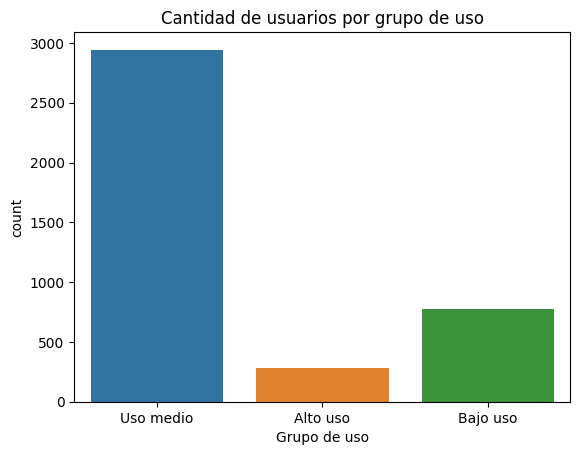

In [57]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Cantidad de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.show()

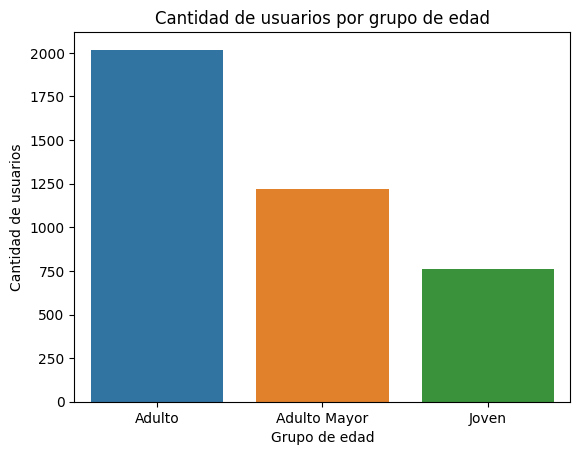

In [58]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Cantidad de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### ¿Qué problemas tenían originalmente los datos?

**1. Valores faltantes (nulos)**

| Dataset | Columna | % de filas afectadas | Acción tomada |
|---|---|---|---|
| `users` | `city` | 11.7% | Investigar e imputar/tratar como corresponda |
| `users` | `churn_date` | 88.35% | No representa un problema de calidad: los nulos indican usuarios activos (sin fecha de cancelación). Se podria transformar en la variable `is_churned` para identificar clientes que cancelaron vs. activos  |
| `usage` | `date` | 0.125% | Imputar (porcentaje mínimo) |
| `usage` | `duration` | 55.19% | Dependiente de `type` — patrón MAR, no requiere imputación |
| `usage` | `length` | 44.74% | Dependiente de `type` — patrón MAR, no requiere imputación |

**2. Valores inválidos y sentinels (disfrazados de datos reales)**

| Columna | Problema | Cantidad / % afectado |
|---|---|---|
| `age` (`users`) | Sentinel `-999` (edad imposible) | 55 registros (1.4%) |
| `city` (`users`) | Sentinel `"?"` (ciudad inexistente) | 96 registros (2.7%) — sumado a los nulos reales, **565 registros (14.1%) con ciudad inválida o faltante** |
| `duration` / `length` (`usage`) | Outliers extremos | Máximos de 120 y 1,490 respectivamente, muy alejados de la media/mediana |

**3. Fechas fuera de rango o inconsistentes**

| Columna | Problema | Cantidad / % afectado |
|---|---|---|
| `reg_date` (`users`) | 40 usuarios registrados en 2026, fuera del periodo cubierto por `usage` (solo 2024) | 40 registros (1% del total de usuarios) |
| `date` (`usage`) | Fechas de uso faltantes | 50 registros (0.125%) |

**4. Columnas sin problemas detectados**
Las columnas `plan`, `type`, `user_id` (en ambos datasets) e `id` no presentaron valores nulos, sentinels, ni inconsistencias — estaban listas para análisis sin necesidad de limpieza adicional.

**Resumen:** entre el 1% y el 14.1% de los registros en las columnas críticas (`city`, `age`, `reg_date`) requirieron corrección antes de poder confiar en los análisis de segmentación y comportamiento de uso, además de una columna completa (`churn_date`) descartada por tener el 88.35% de sus datos faltantes.

### ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

**Segmentación por nivel de uso**

Se clasificó a los usuarios en tres grupos según su cantidad de llamadas y mensajes:

| Grupo de uso | Cantidad aproximada de usuarios | % del total |
|---|---|---|
| Uso medio | ~2,950 | ~73.8% |
| Bajo uso | ~780 | ~19.5% |
| Alto uso | ~280 | ~7% |

La gran mayoría de los usuarios (casi 3 de cada 4) se ubica en el grupo de **Uso medio**, mientras que el segmento de **Alto uso** es notablemente pequeño (7%), consistente con los outliers que identificamos antes en `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada` — son pocos usuarios, pero representan el segmento de consumo más intensivo del servicio.

**Segmentación por edad**

Se clasificó a los usuarios en tres grupos etarios:

| Grupo de edad | Cantidad aproximada de usuarios | % del total |
|---|---|---|
| Adulto (30-59 años) | ~2,020 | ~50.5% |
| Adulto Mayor (60+ años) | ~1,220 | ~30.5% |
| Joven (menor de 30 años) | ~760 | ~19% |

La base de usuarios está compuesta principalmente por **Adultos** (la mitad del total), seguida por **Adultos Mayores** (casi 1 de cada 3), y en menor proporción por **Jóvenes** (menos de 1 de cada 5). Esto sugiere que el servicio tiene una penetración mucho mayor en población adulta y de mayor edad que en usuarios jóvenes.

**Relación entre ambos segmentos**

Considerando ambas segmentaciones en conjunto, el perfil más común de cliente es un **usuario Adulto con Uso medio del servicio**, lo cual representa el segmento base o "típico" de ConnectaTel. Los segmentos menos comunes — **Jóvenes** y usuarios de **Alto uso** — son minoritarios pero valiosos de analizar por separado, ya que podrían representar oportunidades de crecimiento (jóvenes, un mercado con baja penetración actual) o de retención/monetización premium (usuarios de alto uso, que ya mostramos anteriormente con mayor concentración en minutos de llamada dentro del plan Premium).

### ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

**1. Segmento de "Alto uso"**
Aunque es el grupo más pequeño (~7% de los usuarios), representa el segmento con mayor consumo del servicio (más mensajes, más llamadas y, sobre todo, más minutos por llamada). Este grupo es valioso porque:
- Genera más actividad e ingresos potenciales por usuario (si el modelo de negocio cobra por consumo, minutos adicionales, o si estos usuarios son más propensos a pagar por un plan superior).
- Representa a los clientes más "enganchados" con el servicio, con menor riesgo de abandono (churn) si están satisfechos con su experiencia actual.

**2. Usuarios Premium con alto consumo de minutos**
Ya identificamos antes que el segmento con mayor consumo de minutos por llamada (100-155 minutos) se concentra especialmente en el plan **Premium**. Esto es un indicio de que:
- Los usuarios Premium de alto consumo están aprovechando al máximo los beneficios del plan (posiblemente minutos ilimitados o tarifas preferenciales), lo que valida el valor percibido del plan Premium.
- Este segmento es candidato ideal para estrategias de **retención** (evitar que se cambien a la competencia) y **upselling** (ofrecerles beneficios adicionales, ya que claramente valoran el servicio de llamadas).

**3. Segmento Adulto con Uso medio (el "core" de la base de clientes)**
Aunque no es el grupo más "espectacular" en términos de consumo, es el segmento más numeroso (la combinación más común entre edad y uso). Es valioso porque:
- Representa la base estable de ingresos recurrentes de ConnectaTel.
- Cualquier estrategia comercial masiva (nuevos planes, promociones, campañas) debe diseñarse pensando primero en este grupo, ya que es el que más volumen de usuarios mueve.

**4. Oportunidad en el segmento Joven**
Aunque actualmente es el grupo más pequeño (~19% de los usuarios) y no necesariamente el de mayor consumo, podría considerarse valioso desde una perspectiva de **crecimiento futuro**: es un segmento con baja penetración actual, y podría representar una oportunidad comercial si se diseñan planes o promociones dirigidas específicamente a este grupo etario (por ejemplo, planes más económicos, con enfoque en mensajería en lugar de llamadas, dado que las nuevas generaciones suelen preferir el texto sobre las llamadas de voz).

## Conclusión
Los segmentos de **mayor valor inmediato** para ConnectaTel son los usuarios de **Alto uso** y los **Premium de alto consumo de minutos**, ya que concentran el comportamiento más intensivo y rentable. Sin embargo, el segmento **Adulto de Uso medio** sigue siendo el pilar del negocio por su volumen, y el segmento **Joven** representa una oportunidad de expansión a mediano plazo si se ajusta la oferta a sus preferencias de uso.

### ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Al analizar los boxplots de las variables numéricas de comportamiento, se identificaron los siguientes patrones:

**1. `age` — Sin outliers**
No se observan valores atípicos; una vez tratado el sentinel `-999`, la edad se mantiene dentro de un rango humano razonable (18-79 años), sin implicaciones adicionales para el negocio.

**2. `cant_mensajes` — Outliers moderados**
Usuarios con más de 12 mensajes (hasta 17) se alejan del resto (rango típico: 4-7 mensajes), pero la diferencia frente al límite superior (11.5) es moderada (~5.5 mensajes). Representan un pequeño grupo de usuarios con mensajería más intensiva, sin indicios de ser errores de captura.

**3. `cant_llamadas` — Outliers moderados, patrón similar**
Usuarios con más de 11 llamadas (hasta 15) también se alejan del grupo principal (rango típico: 3-6 llamadas), con una diferencia moderada frente al límite (10.5). Al igual que en mensajes, refleja usuarios genuinamente más activos, no anomalías de datos.

**4. `cant_minutos_llamada` — El patrón de outliers más marcado**
Esta variable presenta la mayor cantidad y dispersión de valores atípicos: desde ~65 hasta 155 minutos, muy por encima del límite superior calculado (61.86) — el máximo es **más del doble** de ese límite. Este comportamiento se concentra especialmente en usuarios del plan **Premium**, lo que sugiere un segmento identificable de clientes con consumo de llamadas mucho más intensivo que el resto de la base.

### Implicaciones para el negocio

- **`cant_mensajes` y `cant_llamadas`:** estos outliers no representan un riesgo ni un error — son usuarios más activos dentro de un rango razonable. Se recomienda **mantenerlos** en el análisis, ya que aportan información legítima sobre el comportamiento real de los clientes más comprometidos con el servicio.

- **`cant_minutos_llamada`:** este es el patrón de outliers **más relevante estratégicamente**, porque:
  - Señala un segmento claro de **alto consumo de minutos**, concentrado en Premium, que podría representar a los clientes más rentables o más "enganchados" con el servicio de llamadas.
  - Antes de decidir un tratamiento (capping, eliminación, etc.), es clave **confirmar el sentido de negocio** detrás de este patrón (por ejemplo, si Premium ofrece minutos ilimitados o tarifas especiales para llamadas largas).
  - Si se confirma que es un comportamiento legítimo, la recomendación es **no eliminar ni capear estos valores**, sino documentarlos como un segmento diferenciado de alto consumo. Eliminarlos podría ocultar información valiosa sobre un grupo de clientes potencialmente muy valioso para estrategias de retención o planes premium diferenciados.

**En resumen:** los outliers en `cant_minutos_llamada` no deben tratarse como "ruido" a eliminar, sino como una señal de un segmento de clientes de alto valor que merece atención especial en el diseño de futuras estrategias comerciales (por ejemplo, planes específicos para grandes consumidores de minutos, o campañas de fidelización dirigidas a este grupo).

### ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

**1. Plan diferenciado para el segmento de "Alto uso" / alto consumo de minutos**
Se identificó un grupo pequeño pero valioso de usuarios (concentrado en Premium) con un consumo de minutos por llamada mucho mayor al resto (hasta 155 minutos). Se recomienda:
- Crear o formalizar un **plan "Premium Plus" o "Ilimitado"**, enfocado en minutos de llamada, dirigido específicamente a este segmento de alto consumo.
- Evaluar tarifas especiales o beneficios exclusivos (roaming, prioridad de red, soporte dedicado) para fidelizar a estos clientes, que representan el segmento más rentable y "enganchado" con el servicio.

**2. Plan orientado a mensajería para el segmento Joven**
El segmento **Joven** es actualmente el más pequeño en la base de usuarios (~19%), lo que representa una oportunidad de crecimiento. Dado que las nuevas generaciones suelen preferir mensajería sobre llamadas de voz, se recomienda:
- Diseñar un **plan económico enfocado en mensajes/datos**, con menos énfasis en minutos de llamada, para atraer a este segmento subrepresentado.
- Considerar promociones o paquetes con precios de entrada más accesibles, pensados para un público joven con menor poder adquisitivo o distinto patrón de consumo.

**3. Fortalecer el plan Básico para el segmento "core" (Adulto, Uso medio)**
Este es el segmento más numeroso (Adultos con uso medio representan la mayoría de la base). Se recomienda:
- Mantener el plan Básico como la oferta principal, pero revisar si sus beneficios siguen siendo competitivos, ya que es el plan que sostiene el volumen de ingresos recurrentes.
- Evaluar pequeños ajustes o paquetes intermedios (upgrades incrementales) para incentivar a este grupo a subir gradualmente hacia planes de mayor valor, sin un salto brusco de precio hacia Premium.

**4. Estrategia de retención para Adultos Mayores**
Este segmento representa cerca del 30% de la base y su comportamiento de uso no se exploró en detalle por separado, pero dado su peso significativo, se recomienda:
- Analizar si sus patrones de uso (llamadas vs. mensajes) difieren de los Adultos, para ofrecerles planes ajustados a sus preferencias (por ejemplo, posible mayor preferencia por llamadas sobre mensajería en este grupo).
- Considerar campañas de fidelización, dado que suelen ser clientes de largo plazo y con menor rotación.

**5. Aprovechar el segmento de bajo uso para up-selling**
El grupo de **Bajo uso** (~19.5% de los usuarios) podría representar clientes con potencial no explotado. Se recomienda:
- Investigar si el bajo uso se debe a desconocimiento de beneficios del plan, insatisfacción, o simplemente bajo consumo genuino.
- Diseñar campañas de activación (por ejemplo, minutos o mensajes de bonificación por tiempo limitado) para incentivar mayor uso y evaluar si esto mejora la retención o el upgrade de plan.

## Conclusión general
La oferta actual de ConnectaTel podría beneficiarse de una **segmentación más fina de planes**, en vez de mantener solo dos categorías (Básico/Premium). Se recomienda considerar:
- Un plan de **entrada económico orientado a mensajería** (para atraer al segmento Joven).
- Un plan **intermedio** que retenga al segmento core de Adultos con uso medio.
- Un plan **premium de alto consumo de minutos**, explícitamente diseñado para el segmento de usuarios más intensivos ya identificado.

Esta segmentación más granular permitiría a ConnectaTel capturar mejor el valor de cada grupo de clientes, en vez de aplicar una oferta única que no refleja la diversidad de comportamientos detectada en el análisis.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron valores faltantes significativos: `city` (11.7%, requirió investigación y tratamiento) y `churn_date` (88.35%, sin embargo estos nulos no representan un problema de calidad, sino que indican usuarios activos sin fecha de cancelación); en `usage`, `duration` (55.19%) y `length` (44.74%) resultaron ser nulos estructurales (patrón MAR ligado a `type`), por lo que no requirieron imputación.
- Se detectaron sentinels disfrazados de datos válidos: `-999` en `age` (55 registros) y `"?"` en `city` (96 registros), sumando en esta última un total de 14.1% de datos inválidos o faltantes.
- Se identificaron 40 usuarios registrados en `reg_date` con año 2026, fuera del periodo cubierto por el dataset de uso (solo 2024), por lo que no aportan información de comportamiento y deben excluirse del análisis conjunto.

🔍 **Segmentos por Edad**
- La base de usuarios se compone principalmente de **Adultos** (30-59 años, ~50.5%), seguida de **Adultos Mayores** (60+, ~30.5%) y en menor proporción **Jóvenes** (menores de 30, ~19%).
- El segmento Joven, aunque minoritario, representa una oportunidad de crecimiento dado que hoy tiene la menor penetración dentro del servicio.

📊 **Segmentos por Nivel de Uso**
- La mayoría de los usuarios (73.8%) se ubica en **Uso medio**, mientras que **Alto uso** es un segmento pequeño (~7%) pero con el consumo más intensivo, especialmente en minutos de llamada.
- Los outliers en `cant_minutos_llamada` (hasta 155 minutos, más del doble del límite superior esperado) se concentran en usuarios del plan **Premium**, evidenciando un segmento de alto valor y consumo diferenciado.

➡️ Esto sugiere que el negocio tiene un núcleo estable de clientes Adultos con uso medio (el "core" de ingresos recurrentes), un segmento pequeño pero rentable de alto consumo concentrado en Premium (candidato a retención y upselling), y una oportunidad de expansión en el segmento Joven, actualmente subatendido por la oferta actual de planes.

💡 **Recomendaciones**
- Crear un plan **"Premium Plus" o Ilimitado** enfocado en minutos de llamada, dirigido al segmento de alto consumo ya identificado, con beneficios exclusivos para fidelizarlo.
- Diseñar un plan **económico orientado a mensajería** para atraer al segmento Joven, actualmente subrepresentado.
- Mantener y reforzar el plan **Básico** como pilar del segmento core (Adulto, Uso medio), evaluando paquetes intermedios que faciliten el upgrade gradual hacia planes de mayor valor.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`